# ECGR 4106/5106 — Intro to Deep Learning
## Homework 4 — Transformers

**Name:** Cheikh Thiare  |  **Student ID:** 801310587



## 0. Setup

In [1]:
import time, math, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print("Device:", device)

FAST_MODE = False


Device: cuda


In [2]:
import json, os

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model):
    return count_params(model) * 4 / 1e6

def perplexity(loss):
    return math.exp(loss)

def save_results(name, rows):
    with open(f"results_{name}.json", "w") as f:
        json.dump(rows, f, indent=1)

def load_results(name):
    path = f"results_{name}.json"
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None


### HW2 and HW3 baselines
Recorded results from the earlier assignments, used as the comparison points for the Transformer runs.


In [3]:
# HW2 Problem 1 baselines
hw2_p1 = pd.DataFrame([
    {"model":"RNN","seq_len":10,"train_loss":0.0387,"val_acc":0.4706,"perplexity":28.152,"params":44332,"size_MB":0.177,"train_time_s":1.72},
    {"model":"RNN","seq_len":20,"train_loss":0.0102,"val_acc":0.4705,"perplexity":25.074,"params":44332,"size_MB":0.177,"train_time_s":2.07},
    {"model":"RNN","seq_len":30,"train_loss":0.0082,"val_acc":0.5085,"perplexity":34.189,"params":44332,"size_MB":0.177,"train_time_s":2.55},
    {"model":"LSTM","seq_len":10,"train_loss":0.0390,"val_acc":0.4727,"perplexity":17.223,"params":143404,"size_MB":0.574,"train_time_s":4.22},
    {"model":"LSTM","seq_len":20,"train_loss":0.0110,"val_acc":0.4747,"perplexity":19.088,"params":143404,"size_MB":0.574,"train_time_s":6.06},
    {"model":"LSTM","seq_len":30,"train_loss":0.0061,"val_acc":0.4640,"perplexity":19.991,"params":143404,"size_MB":0.574,"train_time_s":8.69},
    {"model":"GRU","seq_len":10,"train_loss":0.0378,"val_acc":0.5273,"perplexity":18.094,"params":110380,"size_MB":0.442,"train_time_s":2.84},
    {"model":"GRU","seq_len":20,"train_loss":0.0095,"val_acc":0.5295,"perplexity":16.887,"params":110380,"size_MB":0.442,"train_time_s":4.32},
    {"model":"GRU","seq_len":30,"train_loss":0.0044,"val_acc":0.5212,"perplexity":22.539,"params":110380,"size_MB":0.442,"train_time_s":6.07},
])

# HW2 Problem 2 baselines
hw2_p2 = pd.DataFrame([
    {"model":"LSTM","seq_len":20,"train_loss":1.3665,"val_acc":0.5768,"perplexity":3.986,"params":559681,"size_MB":2.239,"train_time_s":240.39,"infer_ms_per_batch":2.510},
    {"model":"LSTM","seq_len":30,"train_loss":1.3279,"val_acc":0.5789,"perplexity":3.957,"params":559681,"size_MB":2.239,"train_time_s":357.14,"infer_ms_per_batch":3.258},
    {"model":"GRU","seq_len":20,"train_loss":1.3892,"val_acc":0.5491,"perplexity":4.431,"params":428097,"size_MB":1.712,"train_time_s":200.89,"infer_ms_per_batch":2.148},
    {"model":"GRU","seq_len":30,"train_loss":1.4251,"val_acc":0.5555,"perplexity":4.342,"params":428097,"size_MB":1.712,"train_time_s":283.04,"infer_ms_per_batch":2.757},
])
hw2_p2_seq50 = pd.DataFrame([
    {"model":"LSTM","seq_len":50,"train_loss":1.3435,"val_acc":0.5784,"perplexity":3.937,"params":559681,"size_MB":2.239,"train_time_s":551.39,"infer_ms_per_batch":5.177},
    {"model":"GRU","seq_len":50,"train_loss":1.7893,"val_acc":0.5524,"perplexity":4.389,"params":428097,"size_MB":1.712,"train_time_s":458.59,"infer_ms_per_batch":4.312},
])

# HW3 baselines
hw3 = pd.DataFrame([
    {"label":"GRU baseline","direction":"en-fr","attention":False,"seq_acc":0.000,"bleu4":0.1500,"final_train_loss":0.000029,"final_val_loss":7.0746,"train_time_s":395.8,"params":1527007},
    {"label":"GRU + attention","direction":"en-fr","attention":True,"seq_acc":0.000,"bleu4":0.1514,"final_train_loss":0.000704,"final_val_loss":5.3870,"train_time_s":572.4,"params":1666030},
    {"label":"GRU baseline","direction":"fr-en","attention":False,"seq_acc":0.000,"bleu4":0.1328,"final_train_loss":0.002252,"final_val_loss":6.0396,"train_time_s":398.4,"params":None},
    {"label":"GRU + attention","direction":"fr-en","attention":True,"seq_acc":0.000,"bleu4":0.1088,"final_train_loss":0.225729,"final_val_loss":4.8674,"train_time_s":567.5,"params":None},
])
print("HW2 P1 rows:", len(hw2_p1), "| HW2 P2 rows:", len(hw2_p2), "| HW3 rows:", len(hw3))


HW2 P1 rows: 9 | HW2 P2 rows: 4 | HW3 rows: 4


### Shared Transformer building blocks
Sinusoidal positional encoding and an encoder-style classifier that predicts the next character from a
fixed window. This matches how the HW2 recurrent models read a window and predicted a single next
character, so the metrics line up directly.


In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class CharTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=2, num_layers=2,
                 dim_ff=None, dropout=0.1):
        super().__init__()
        dim_ff = dim_ff or 4 * d_model
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout,
                                           batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers)
        self.fc = nn.Linear(d_model, vocab_size)
    def forward(self, x):
        h = self.pos(self.embedding(x) * math.sqrt(self.d_model))
        h = self.encoder(h)
        return self.fc(h[:, -1, :])


# Problem 1 — Character-Level Transformer vs. RNN (20 pts)


In [5]:
text_p1 = (
"Next character prediction is a fundamental task in the field of natural language "
"processing (NLP) that involves predicting the next character in a sequence of text "
"based on the characters that precede it. This task is essential for various "
"applications, including text auto-completion, spell checking, and even in the "
"development of sophisticated AI models capable of generating human-like text. "
"At its core, next character prediction relies on statistical models or deep learning "
"algorithms to analyze a given sequence of text and predict which character is most "
"likely to follow. These predictions are based on patterns and relationships learned "
"from large datasets of text during the training phase of the model. "
"One of the most popular approaches to next character prediction involves the use of "
"Recurrent Neural Networks (RNNs), and more specifically, a variant called Long "
"Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential "
"data like text, as they can maintain information in 'memory' about previous characters "
"to inform the prediction of the next character. LSTM networks enhance this capability "
"by being able to remember long-term dependencies, making them even more effective for "
"next character prediction tasks. "
"Training a model for next character prediction involves feeding it large amounts of "
"text data, allowing it to learn the probability of each character's appearance "
"following a sequence of characters. During this training process, the model adjusts "
"its parameters to minimize the difference between its predictions and the actual "
"outcomes, thus improving its predictive accuracy over time. "
"Once trained, the model can be used to predict the next character in a given piece of "
"text by considering the sequence of characters that precede it. This can enhance user "
"experience in text editing software, improve efficiency in coding environments with "
"auto-completion features, and enable more natural interactions with AI-based chatbots "
"and virtual assistants. "
"In summary, next character prediction plays a crucial role in enhancing the "
"capabilities of various NLP applications, making text-based interactions more "
"efficient, accurate, and human-like. Through the use of advanced machine learning "
"models like RNNs and LSTMs, next character prediction continues to evolve, opening "
"new possibilities for the future of text-based technology.")

chars_p1 = sorted(list(set(text_p1)))
stoi_p1 = {c: i for i, c in enumerate(chars_p1)}
itos_p1 = {i: c for i, c in enumerate(chars_p1)}
vocab_p1 = len(chars_p1)
print("Passage length:", len(text_p1), "characters | vocab size:", vocab_p1)


Passage length: 2386 characters | vocab size: 44


In [6]:
def build_dataset_p1(seq_len):
    X, y = [], []
    for i in range(len(text_p1) - seq_len):
        X.append([stoi_p1[c] for c in text_p1[i:i+seq_len]])
        y.append(stoi_p1[text_p1[i+seq_len]])
    X, y = np.array(X), np.array(y)
    Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
    to = lambda a: torch.tensor(a, dtype=torch.long).to(device)
    return to(Xtr), to(ytr), to(Xv), to(yv)


In [7]:
def train_p1_tf(seq_len, d_model=128, nhead=2, num_layers=2,
                epochs=200, lr=3e-3, batch_size=128):
    Xtr, ytr, Xv, yv = build_dataset_p1(seq_len)
    model = CharTransformer(vocab_p1, d_model, nhead, num_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    n = Xtr.size(0)
    losses = []
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        ep_loss = 0.0; nb = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            loss = crit(model(Xtr[idx]), ytr[idx])
            loss.backward(); opt.step()
            ep_loss += loss.item(); nb += 1
        losses.append(ep_loss / nb)
    train_time = time.time() - t0
    model.eval()
    with torch.no_grad():
        out = model(Xv)
        val_loss = crit(out, yv).item()
        val_acc = (out.argmax(1) == yv).float().mean().item()
    return {
        "model": "Transformer", "seq_len": seq_len,
        "train_loss": round(losses[-1], 4),
        "val_acc": round(val_acc, 4),
        "perplexity": round(perplexity(val_loss), 3),
        "params": count_params(model),
        "size_MB": round(model_size_mb(model), 3),
        "train_time_s": round(train_time, 2),
    }, losses


In [8]:
P1_EPOCHS = 40 if FAST_MODE else 200
results_p1, curves_p1 = [], {}
for seq_len in [10, 20, 30]:
    res, losses = train_p1_tf(seq_len, epochs=P1_EPOCHS)
    results_p1.append(res); curves_p1[seq_len] = losses
    print(res)

df_p1 = pd.DataFrame(results_p1)
save_results("p1", results_p1)
df_p1


{'model': 'Transformer', 'seq_len': 10, 'train_loss': 0.3762, 'val_acc': 0.3592, 'perplexity': 114.235, 'params': 407852, 'size_MB': 1.631, 'train_time_s': 18.28}
{'model': 'Transformer', 'seq_len': 20, 'train_loss': 0.3624, 'val_acc': 0.3017, 'perplexity': 199.427, 'params': 407852, 'size_MB': 1.631, 'train_time_s': 19.77}
{'model': 'Transformer', 'seq_len': 30, 'train_loss': 0.4273, 'val_acc': 0.2267, 'perplexity': 244.351, 'params': 407852, 'size_MB': 1.631, 'train_time_s': 20.23}


,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s
0,Transformer,10,0.3762,0.3592,114.235,407852,1.631,18.28
1,Transformer,20,0.3624,0.3017,199.427,407852,1.631,19.77
2,Transformer,30,0.4273,0.2267,244.351,407852,1.631,20.23


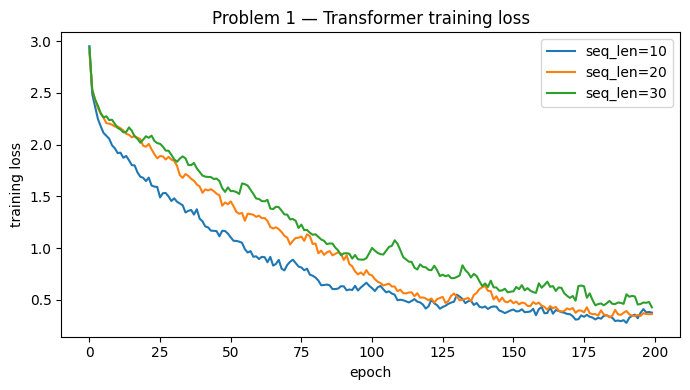

In [9]:
plt.figure(figsize=(7, 4))
for seq_len, losses in curves_p1.items():
    plt.plot(losses, label=f"seq_len={seq_len}")
plt.xlabel("epoch"); plt.ylabel("training loss")
plt.title("Problem 1 — Transformer training loss"); plt.legend()
plt.tight_layout(); plt.show()


In [10]:
# compare against the best recurrent baseline at each sequence length
best_rnn = (hw2_p1.sort_values("val_acc", ascending=False)
            .groupby("seq_len").first().reset_index()
            .rename(columns={"model":"best_rnn"}))
cmp_p1 = df_p1.merge(best_rnn, on="seq_len", suffixes=("_tf", "_rnn"))
cmp_p1 = cmp_p1[["seq_len","val_acc_tf","val_acc_rnn","best_rnn",
                 "perplexity_tf","perplexity_rnn",
                 "params_tf","params_rnn","train_time_s_tf","train_time_s_rnn"]]
cmp_p1


,seq_len,val_acc_tf,val_acc_rnn,best_rnn,perplexity_tf,perplexity_rnn,params_tf,params_rnn,train_time_s_tf,train_time_s_rnn
0,10,0.3592,0.5273,GRU,114.235,18.094,407852,110380,18.28,2.84
1,20,0.3017,0.5295,GRU,199.427,16.887,407852,110380,19.77,4.32
2,30,0.2267,0.5212,GRU,244.351,22.539,407852,110380,20.23,6.07


# Problem 2 — Transformer for Character Prediction on Tiny Shakespeare (20 pts)


In [11]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    import requests
    full_text = requests.get(url).text
except Exception:
    full_text = urllib.request.urlopen(url).read().decode("utf-8")

text_p2 = full_text[:150_000] if FAST_MODE else full_text[:300_000]
chars_p2 = sorted(list(set(text_p2)))
stoi_p2 = {c: i for i, c in enumerate(chars_p2)}
itos_p2 = {i: c for i, c in enumerate(chars_p2)}
vocab_p2 = len(chars_p2)
encoded_p2 = [stoi_p2[c] for c in text_p2]
print("Using", len(text_p2), "characters | vocab size:", vocab_p2)


Using 300000 characters | vocab size: 62


In [12]:
class CharDataset(Dataset):
    def __init__(self, encoded, seq_len):
        seqs, tgts = [], []
        for i in range(len(encoded) - seq_len):
            seqs.append(encoded[i:i+seq_len]); tgts.append(encoded[i+seq_len])
        self.sequences = torch.tensor(seqs, dtype=torch.long)
        self.targets = torch.tensor(tgts, dtype=torch.long)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, i): return self.sequences[i], self.targets[i]

def make_loaders(seq_len, batch_size=256):
    ds = CharDataset(encoded_p2, seq_len)
    n_tr = int(len(ds) * 0.8)
    tr, te = random_split(ds, [n_tr, len(ds) - n_tr],
                          generator=torch.Generator().manual_seed(42))
    return (DataLoader(tr, batch_size=batch_size, shuffle=True),
            DataLoader(te, batch_size=batch_size, shuffle=False))


In [13]:
@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval(); tot = correct = 0; loss_sum = nb = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss_sum += crit(out, yb).item(); nb += 1
        correct += (out.argmax(1) == yb).sum().item(); tot += yb.size(0)
    return loss_sum / nb, correct / tot

def train_p2_tf(seq_len, d_model=256, nhead=2, num_layers=2, dim_ff=None,
                epochs=10, lr=1e-3, batch_size=256, label=None):
    train_loader, test_loader = make_loaders(seq_len, batch_size)
    model = CharTransformer(vocab_p2, d_model, nhead, num_layers, dim_ff).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
    train_time = time.time() - t0

    model.eval(); t1 = time.time()
    with torch.no_grad():
        for xb, _ in test_loader:
            model(xb.to(device))
    infer_time = (time.time() - t1) / max(len(test_loader), 1) * 1000

    val_loss, val_acc = evaluate(model, test_loader, crit)
    return model, {
        "label": label or f"{num_layers}blk-{nhead}h",
        "blocks": num_layers, "heads": nhead, "seq_len": seq_len,
        "train_loss": round(loss.item(), 4),
        "val_acc": round(val_acc, 4),
        "perplexity": round(perplexity(val_loss), 3),
        "params": count_params(model),
        "size_MB": round(model_size_mb(model), 3),
        "train_time_s": round(train_time, 2),
        "infer_ms_per_batch": round(infer_time, 3),
    }


In [14]:
@torch.no_grad()
def generate(model, seed, length=200, seq_len=30):
    model.eval()
    s = seed
    for _ in range(length):
        ctx = [stoi_p2.get(c, 0) for c in s[-seq_len:]]
        x = torch.tensor([ctx], dtype=torch.long).to(device)
        nxt = model(x).argmax(1).item()
        s += itos_p2[nxt]
    return s


## Problem 2.1 — Starting configuration (2 blocks, 2 heads) at sequence lengths 20 and 30

In [15]:
P2_EPOCHS = 3 if FAST_MODE else 10
results_p21 = []
for seq_len in [20, 30]:
    _, res = train_p2_tf(seq_len, d_model=256, nhead=2, num_layers=2, epochs=P2_EPOCHS)
    results_p21.append(res); print(res)

df_p21 = pd.DataFrame(results_p21)[
    ["blocks","heads","seq_len","train_loss","val_acc","perplexity",
     "params","size_MB","train_time_s","infer_ms_per_batch"]]
save_results("p21", results_p21)
df_p21


{'label': '2blk-2h', 'blocks': 2, 'heads': 2, 'seq_len': 20, 'train_loss': 1.826, 'val_acc': 0.3923, 'perplexity': 7.679, 'params': 1611326, 'size_MB': 6.445, 'train_time_s': 211.42, 'infer_ms_per_batch': 6.935}
{'label': '2blk-2h', 'blocks': 2, 'heads': 2, 'seq_len': 30, 'train_loss': 2.0817, 'val_acc': 0.3093, 'perplexity': 10.275, 'params': 1611326, 'size_MB': 6.445, 'train_time_s': 318.97, 'infer_ms_per_batch': 10.736}


,blocks,heads,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s,infer_ms_per_batch
0,2,2,20,1.8260,0.3923,7.679,1611326,6.445,211.42,6.935
1,2,2,30,2.0817,0.3093,10.275,1611326,6.445,318.97,10.736


In [16]:
cmp_p21 = pd.concat([
    df_p21.assign(model="Transformer(2blk-2h)")[
        ["model","seq_len","train_loss","val_acc","perplexity","params","size_MB","train_time_s","infer_ms_per_batch"]],
    hw2_p2[["model","seq_len","train_loss","val_acc","perplexity","params","size_MB","train_time_s","infer_ms_per_batch"]],
], ignore_index=True).sort_values(["seq_len","model"])
cmp_p21


,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s,infer_ms_per_batch
4,GRU,20,1.3892,0.5491,4.431,428097,1.712,200.89,2.148
2,LSTM,20,1.3665,0.5768,3.986,559681,2.239,240.39,2.510
0,Transformer(2blk-2h),20,1.8260,0.3923,7.679,1611326,6.445,211.42,6.935
5,GRU,30,1.4251,0.5555,4.342,428097,1.712,283.04,2.757
3,LSTM,30,1.3279,0.5789,3.957,559681,2.239,357.14,3.258
1,Transformer(2blk-2h),30,2.0817,0.3093,10.275,1611326,6.445,318.97,10.736


## Problem 2.2 — Blocks × heads sweep

Blocks ∈ {1, 2, 4} and heads ∈ {2, 4}, giving six configurations. All six are run at a fixed
sequence length of 30.


In [17]:
GRID_BLOCKS = [1, 2, 4]
GRID_HEADS  = [2, 4]
SWEEP_EPOCHS = 3 if FAST_MODE else 8
SWEEP_SEQ = 30

results_p22, models_p22 = [], {}
for blk in GRID_BLOCKS:
    for h in GRID_HEADS:
        model, res = train_p2_tf(SWEEP_SEQ, d_model=256, nhead=h, num_layers=blk,
                                 epochs=SWEEP_EPOCHS, label=f"{blk}blk-{h}h")
        results_p22.append(res); models_p22[res["label"]] = model
        save_results("p22", results_p22)
        print(res)

df_p22 = pd.DataFrame(results_p22)[
    ["label","blocks","heads","train_loss","val_acc","perplexity",
     "params","size_MB","train_time_s","infer_ms_per_batch"]]
save_results("p22", results_p22)
df_p22


{'label': '1blk-2h', 'blocks': 1, 'heads': 2, 'seq_len': 30, 'train_loss': 2.2736, 'val_acc': 0.2786, 'perplexity': 11.364, 'params': 821566, 'size_MB': 3.286, 'train_time_s': 126.21, 'infer_ms_per_batch': 5.424}
{'label': '1blk-4h', 'blocks': 1, 'heads': 4, 'seq_len': 30, 'train_loss': 2.5469, 'val_acc': 0.2785, 'perplexity': 11.328, 'params': 821566, 'size_MB': 3.286, 'train_time_s': 127.49, 'infer_ms_per_batch': 5.475}
{'label': '2blk-2h', 'blocks': 2, 'heads': 2, 'seq_len': 30, 'train_loss': 2.4451, 'val_acc': 0.3086, 'perplexity': 10.157, 'params': 1611326, 'size_MB': 6.445, 'train_time_s': 255.3, 'infer_ms_per_batch': 10.713}
{'label': '2blk-4h', 'blocks': 2, 'heads': 4, 'seq_len': 30, 'train_loss': 1.9539, 'val_acc': 0.3789, 'perplexity': 8.117, 'params': 1611326, 'size_MB': 6.445, 'train_time_s': 255.52, 'infer_ms_per_batch': 10.604}
{'label': '4blk-2h', 'blocks': 4, 'heads': 2, 'seq_len': 30, 'train_loss': 2.2248, 'val_acc': 0.3309, 'perplexity': 9.567, 'params': 3190846, 'siz

,label,blocks,heads,train_loss,val_acc,perplexity,params,size_MB,train_time_s,infer_ms_per_batch
0,1blk-2h,1,2,2.2736,0.2786,11.364,821566,3.286,126.21,5.424
1,1blk-4h,1,4,2.5469,0.2785,11.328,821566,3.286,127.49,5.475
2,2blk-2h,2,2,2.4451,0.3086,10.157,1611326,6.445,255.30,10.713
3,2blk-4h,2,4,1.9539,0.3789,8.117,1611326,6.445,255.52,10.604
4,4blk-2h,4,2,2.2248,0.3309,9.567,3190846,12.763,506.47,20.842
5,4blk-4h,4,4,2.3237,0.3397,9.239,3190846,12.763,513.25,21.237


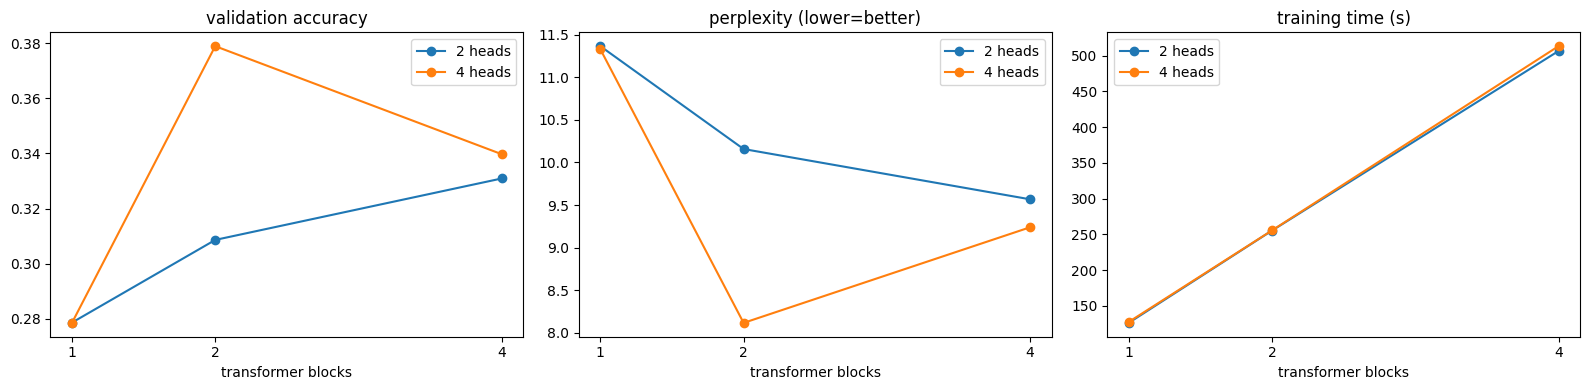

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (col, title) in zip(ax, [("val_acc","validation accuracy"),
                                 ("perplexity","perplexity (lower=better)"),
                                 ("train_time_s","training time (s)")]):
    for h in GRID_HEADS:
        sub = df_p22[df_p22.heads == h]
        a.plot(sub.blocks, sub[col], marker="o", label=f"{h} heads")
    a.set_xlabel("transformer blocks"); a.set_title(title)
    a.set_xticks(GRID_BLOCKS); a.legend()
plt.tight_layout(); plt.show()


## Problem 2.3 — Sequence length 50

In [19]:
_, res_p23 = train_p2_tf(50, d_model=256, nhead=2, num_layers=2, epochs=P2_EPOCHS,
                         label="Transformer(2blk-2h) seq50")
df_p23 = pd.concat([
    pd.DataFrame([res_p23]).assign(model="Transformer(2blk-2h)")[
        ["model","seq_len","train_loss","val_acc","perplexity","params","size_MB","train_time_s","infer_ms_per_batch"]],
    hw2_p2_seq50[["model","seq_len","train_loss","val_acc","perplexity","params","size_MB","train_time_s","infer_ms_per_batch"]],
], ignore_index=True)
save_results("p23", [res_p23])
df_p23


,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s,infer_ms_per_batch
0,Transformer(2blk-2h),50,2.1502,0.3139,10.096,1611326,6.445,516.30,17.474
1,LSTM,50,1.3435,0.5784,3.937,559681,2.239,551.39,5.177
2,GRU,50,1.7893,0.5524,4.389,428097,1.712,458.59,4.312


In [20]:
seed = "ROMEO: "
for label, model in list(models_p22.items())[:3]:
    print(f"--- {label} ---")
    print(generate(model, seed, length=160, seq_len=SWEEP_SEQ))
    print()


--- 1blk-2h ---
ROMEO: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the 

--- 1blk-4h ---
ROMEO: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the 

--- 2blk-2h ---
ROMEO: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the 



# Problem 3 — Transformer Encoder–Decoder, English→French (40 pts)


In [21]:
import os, re, random
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

SEED = 42
random.seed(SEED); torch.manual_seed(SEED)
smooth = SmoothingFunction().method4

if not os.path.exists("vast_english_french.txt"):
    from google.colab import files
    files.upload()

def normalize(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?,])", r" \1 ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

pairs = []
with open("vast_english_french.txt", encoding="utf-8") as f:
    for line in f:
        if "\t" not in line: continue
        en, fr = line.rstrip("\n").split("\t")
        pairs.append((normalize(en), normalize(fr)))

random.shuffle(pairs)
n_train = int(0.8 * len(pairs))
train_pairs, val_pairs = pairs[:n_train], pairs[n_train:]
MAX_LENGTH = max(max(len(a.split()), len(b.split())) for a, b in pairs) + 1
print(f"pairs: {len(pairs)} | train: {len(train_pairs)} | val: {len(val_pairs)} | MAX_LENGTH: {MAX_LENGTH}")

def view(direction):
    if direction == "en-fr":
        return train_pairs[:], val_pairs[:]
    return [(b, a) for a, b in train_pairs], [(b, a) for a, b in val_pairs]


pairs: 555 | train: 444 | val: 111 | MAX_LENGTH: 15


In [22]:
PAD, BOS, EOS, UNK = 0, 1, 2, 3

class TVocab:
    def __init__(self):
        self.w2i = {"<pad>": PAD, "<bos>": BOS, "<eos>": EOS, "<unk>": UNK}
        self.i2w = {i: w for w, i in self.w2i.items()}
        self.n = 4
    def add(self, sentence):
        for w in sentence.split(" "):
            if w not in self.w2i:
                self.w2i[w] = self.n; self.i2w[self.n] = w; self.n += 1
    def encode(self, sentence):
        return [self.w2i.get(w, UNK) for w in sentence.split(" ")]

def build_vocab(train):
    src, tgt = TVocab(), TVocab()
    for s, t in train:
        src.add(s); tgt.add(t)
    return src, tgt

def make_examples(pairs, src_vocab, tgt_vocab):
    data = []
    for s, t in pairs:
        src = src_vocab.encode(s) + [EOS]
        tgt = tgt_vocab.encode(t)
        data.append((src, [BOS] + tgt, tgt + [EOS]))
    return data

def collate(batch):
    def pad(seqs):
        m = max(len(x) for x in seqs)
        return torch.tensor([x + [PAD] * (m - len(x)) for x in seqs], dtype=torch.long)
    src, tin, tout = zip(*batch)
    return pad(src).to(device), pad(tin).to(device), pad(tout).to(device)


In [23]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=256, nhead=4, num_layers=2,
                 dim_ff=512, dropout=0.1, max_len=64):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD)
        self.pos = PositionalEncoding(d_model, max_len)
        self.transformer = nn.Transformer(d_model, nhead, num_layers, num_layers,
                                          dim_ff, dropout, batch_first=True)
        self.fc = nn.Linear(d_model, tgt_vocab)
    def _emb(self, tokens, emb):
        return self.pos(emb(tokens) * math.sqrt(self.d_model))
    def forward(self, src, tgt_in):
        src_pad = (src == PAD); tgt_pad = (tgt_in == PAD)
        tmask = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1)).to(device)
        out = self.transformer(self._emb(src, self.src_emb),
                               self._emb(tgt_in, self.tgt_emb),
                               tgt_mask=tmask,
                               src_key_padding_mask=src_pad,
                               tgt_key_padding_mask=tgt_pad,
                               memory_key_padding_mask=src_pad)
        return self.fc(out)

@torch.no_grad()
def greedy_translate(model, src_ids, tgt_vocab, max_len=None):
    model.eval()
    max_len = max_len or (MAX_LENGTH + 2)
    src = torch.tensor([src_ids], device=device)
    src_pad = (src == PAD)
    mem = model.transformer.encoder(model._emb(src, model.src_emb),
                                    src_key_padding_mask=src_pad)
    ys = torch.tensor([[BOS]], device=device)
    for _ in range(max_len):
        tmask = nn.Transformer.generate_square_subsequent_mask(ys.size(1)).to(device)
        dec = model.transformer.decoder(model._emb(ys, model.tgt_emb), mem,
                                        tgt_mask=tmask, memory_key_padding_mask=src_pad)
        nxt = model.fc(dec[:, -1]).argmax(-1).item()
        if nxt == EOS: break
        ys = torch.cat([ys, torch.tensor([[nxt]], device=device)], dim=1)
    return [tgt_vocab.i2w.get(i, "<unk>") for i in ys[0, 1:].tolist()]


In [24]:
def seq_acc_bleu(model, val, src_vocab, tgt_vocab):
    refs, hyps, exact = [], [], 0
    for s, t in val:
        pred = greedy_translate(model, src_vocab.encode(s) + [EOS], tgt_vocab)
        tgt_words = t.split(" ")
        hyps.append(pred); refs.append([tgt_words])
        if pred == tgt_words: exact += 1
    bleu = corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25),
                       smoothing_function=smooth)
    return exact / len(val), bleu

@torch.no_grad()
def val_loss_fn(model, loader, crit):
    model.eval(); tot = 0.0; nb = 0
    for src, tin, tout in loader:
        logits = model(src, tin)
        tot += crit(logits.reshape(-1, logits.size(-1)), tout.reshape(-1)).item(); nb += 1
    return tot / nb

def train_transformer(direction, blocks, heads, epochs=50, d_model=256,
                      dim_ff=512, dropout=0.1, lr=5e-4, batch_size=32, verbose=False):
    train, val = view(direction)
    src_vocab, tgt_vocab = build_vocab(train)
    train_loader = DataLoader(make_examples(train, src_vocab, tgt_vocab),
                              batch_size=batch_size, shuffle=True, collate_fn=collate)
    val_loader = DataLoader(make_examples(val, src_vocab, tgt_vocab),
                            batch_size=batch_size, shuffle=False, collate_fn=collate)
    model = Seq2SeqTransformer(src_vocab.n, tgt_vocab.n, d_model, heads, blocks,
                               dim_ff, dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(ignore_index=PAD)
    tr_hist, va_hist = [], []
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tot = 0.0; nb = 0
        for src, tin, tout in train_loader:
            opt.zero_grad()
            logits = model(src, tin)
            loss = crit(logits.reshape(-1, logits.size(-1)), tout.reshape(-1))
            loss.backward(); opt.step(); tot += loss.item(); nb += 1
        tr_hist.append(tot / nb)
        va_hist.append(val_loss_fn(model, val_loader, crit))
        if verbose and (ep == 0 or (ep + 1) % 10 == 0):
            print(f"  [{direction} {blocks}blk-{heads}h] epoch {ep+1}/{epochs} "
                  f"train {tr_hist[-1]:.3f} val {va_hist[-1]:.3f}")
    acc, bleu = seq_acc_bleu(model, val, src_vocab, tgt_vocab)
    res = {"label": f"{blocks}blk-{heads}h", "direction": direction,
           "blocks": blocks, "heads": heads,
           "seq_acc": round(acc, 4), "bleu4": round(bleu, 4),
           "final_train_loss": round(tr_hist[-1], 4),
           "final_val_loss": round(va_hist[-1], 4),
           "train_time_s": round(time.time() - t0, 1),
           "params": count_params(model)}
    return model, (src_vocab, tgt_vocab), (tr_hist, va_hist), res


### Sweep: blocks ∈ {1, 2, 4} × heads ∈ {2, 4}

The same six configurations used in Problem 2.


In [25]:
GRID_BLOCKS = [1, 2, 4]
GRID_HEADS  = [2, 4]
TRANS_EPOCHS = 10 if FAST_MODE else 35

runs_enfr, results_p3 = {}, []
for blk in GRID_BLOCKS:
    for h in GRID_HEADS:
        model, vocabs, hist, res = train_transformer("en-fr", blk, h, epochs=TRANS_EPOCHS)
        runs_enfr[res["label"]] = (model, vocabs, hist, res)
        results_p3.append(res)
        save_results("p3", results_p3)
        print(f"{res['label']}: seq_acc={res['seq_acc']:.3f} BLEU-4={res['bleu4']:.4f} "
              f"val_loss={res['final_val_loss']:.3f} time={res['train_time_s']}s")

df_p3 = pd.DataFrame(results_p3)[
    ["label","blocks","heads","final_train_loss","final_val_loss","seq_acc","bleu4","params","train_time_s"]]
save_results("p3", results_p3)
df_p3


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


1blk-2h: seq_acc=0.000 BLEU-4=0.1553 val_loss=4.369 time=6.4s
1blk-4h: seq_acc=0.000 BLEU-4=0.1834 val_loss=4.309 time=6.9s
2blk-2h: seq_acc=0.000 BLEU-4=0.1898 val_loss=4.141 time=11.5s
2blk-4h: seq_acc=0.000 BLEU-4=0.1879 val_loss=4.027 time=11.4s
4blk-2h: seq_acc=0.009 BLEU-4=0.1691 val_loss=4.233 time=20.0s
4blk-4h: seq_acc=0.000 BLEU-4=0.1668 val_loss=4.101 time=20.4s


,label,blocks,heads,final_train_loss,final_val_loss,seq_acc,bleu4,params,train_time_s
0,1blk-2h,1,2,0.1436,4.3688,0.000,0.1553,2057953,6.4
1,1blk-4h,1,4,0.0989,4.3088,0.000,0.1834,2057953,6.9
2,2blk-2h,2,2,0.0846,4.1409,0.000,0.1898,3375841,11.5
3,2blk-4h,2,4,0.0682,4.0272,0.000,0.1879,3375841,11.4
4,4blk-2h,4,2,0.1306,4.2326,0.009,0.1691,6011617,20.0
5,4blk-4h,4,4,0.1092,4.1013,0.000,0.1668,6011617,20.4


Best EN->FR config by BLEU-4: 2blk-2h


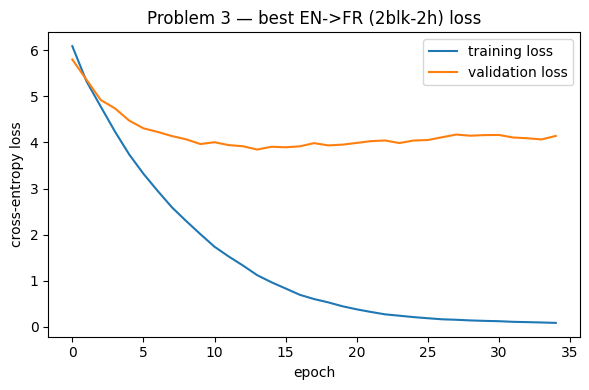

In [26]:
best_label_enfr = df_p3.sort_values("bleu4", ascending=False).iloc[0]["label"]
best_model, best_vocabs, best_hist, best_res = runs_enfr[best_label_enfr]
print("Best EN->FR config by BLEU-4:", best_label_enfr)

tr, va = best_hist
plt.figure(figsize=(6, 4))
plt.plot(tr, label="training loss"); plt.plot(va, label="validation loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title(f"Problem 3 — best EN->FR ({best_label_enfr}) loss"); plt.legend()
plt.tight_layout(); plt.show()


In [27]:
def show_samples(model, vocabs, val, k=5):
    src_vocab, tgt_vocab = vocabs
    for s, t in val[:k]:
        pred = greedy_translate(model, src_vocab.encode(s) + [EOS], tgt_vocab)
        pred_s = " ".join(pred)
        sb = sentence_bleu([t.split()], pred, weights=(0.25,) * 4, smoothing_function=smooth)
        print(f"SRC : {s}")
        print(f"PRED: {pred_s}")
        print(f"TGT : {t}")
        print(f"      exact_match={pred_s == t}  sentence_BLEU-4={sb:.3f}\n")

print(f"Qualitative validation — best EN->FR config ({best_label_enfr}):\n")
show_samples(best_model, best_vocabs, view("en-fr")[1], k=6)


Qualitative validation — best EN->FR config (2blk-2h):

SRC : they feed the pigeons in the square
PRED: ils nourrissent les oiseaux dans le ciel
TGT : ils nourrissent les pigeons sur la place
      exact_match=False  sentence_BLEU-4=0.193

SRC : she practices yoga every morning
PRED: elle joue du matin
TGT : elle pratique le yoga tous les matins
      exact_match=False  sentence_BLEU-4=0.029

SRC : i enjoy walking in the snow
PRED: j'aime marcher sous la forêt dense
TGT : j'aime marcher dans la neige
      exact_match=False  sentence_BLEU-4=0.108

SRC : she loves to wear modern jackets
PRED: elle adore porter des vestes en cuir modernes
TGT : elle adore porter des vestes modernes
      exact_match=False  sentence_BLEU-4=0.541

SRC : the city bus arrives precisely at five o'clock
PRED: le bus arrive à cinq heures
TGT : le bus de la ville arrive précisément à cinq heures
      exact_match=False  sentence_BLEU-4=0.158

SRC : we visited the historical ruins of the pyramid
PRED: nous avons 

In [28]:
cmp_p3 = pd.concat([
    pd.DataFrame([{**best_res, "label": f"Transformer ({best_label_enfr})"}]),
    hw3[hw3.direction == "en-fr"],
], ignore_index=True)[["label","attention","seq_acc","bleu4","final_train_loss","final_val_loss","train_time_s","params"]]
cmp_p3


,label,attention,seq_acc,bleu4,final_train_loss,final_val_loss,train_time_s,params
0,Transformer (2blk-2h),NaN,0.0,0.1898,0.084600,4.1409,11.5,3375841.0
1,GRU baseline,False,0.0,0.1500,0.000029,7.0746,395.8,1527007.0
2,GRU + attention,True,0.0,0.1514,0.000704,5.3870,572.4,1666030.0


# Problem 4 — Reversing the Direction: French→English (20 pts)

**Objective.** Repeat Problem 3 with the translation direction reversed (French→English), on the same
split and the same 6 block×head configurations. Report the same metrics, show qualitative
translations, compare against the HW3 GRU FR→EN models, and conclude with which direction the
Transformer optimized more easily.

In [29]:
runs_fren, results_p4 = {}, []
for blk in GRID_BLOCKS:
    for h in GRID_HEADS:
        model, vocabs, hist, res = train_transformer("fr-en", blk, h, epochs=TRANS_EPOCHS)
        runs_fren[res["label"]] = (model, vocabs, hist, res)
        results_p4.append(res)
        save_results("p4", results_p4)
        print(f"{res['label']}: seq_acc={res['seq_acc']:.3f} BLEU-4={res['bleu4']:.4f} "
              f"val_loss={res['final_val_loss']:.3f} time={res['train_time_s']}s")

df_p4 = pd.DataFrame(results_p4)[
    ["label","blocks","heads","final_train_loss","final_val_loss","seq_acc","bleu4","params","train_time_s"]]
save_results("p4", results_p4)
df_p4


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


1blk-2h: seq_acc=0.000 BLEU-4=0.1501 val_loss=4.189 time=6.6s
1blk-4h: seq_acc=0.000 BLEU-4=0.1568 val_loss=4.104 time=6.5s
2blk-2h: seq_acc=0.000 BLEU-4=0.1776 val_loss=3.890 time=11.2s
2blk-4h: seq_acc=0.000 BLEU-4=0.1618 val_loss=3.863 time=11.3s
4blk-2h: seq_acc=0.000 BLEU-4=0.1576 val_loss=3.886 time=20.9s
4blk-4h: seq_acc=0.000 BLEU-4=0.1560 val_loss=3.765 time=19.8s


,label,blocks,heads,final_train_loss,final_val_loss,seq_acc,bleu4,params,train_time_s
0,1blk-2h,1,2,0.1155,4.1895,0.0,0.1501,2033281,6.6
1,1blk-4h,1,4,0.0835,4.1037,0.0,0.1568,2033281,6.5
2,2blk-2h,2,2,0.0832,3.8898,0.0,0.1776,3351169,11.2
3,2blk-4h,2,4,0.0600,3.8632,0.0,0.1618,3351169,11.3
4,4blk-2h,4,2,0.1082,3.8856,0.0,0.1576,5986945,20.9
5,4blk-4h,4,4,0.1131,3.7655,0.0,0.1560,5986945,19.8


Best FR->EN config by BLEU-4: 2blk-2h


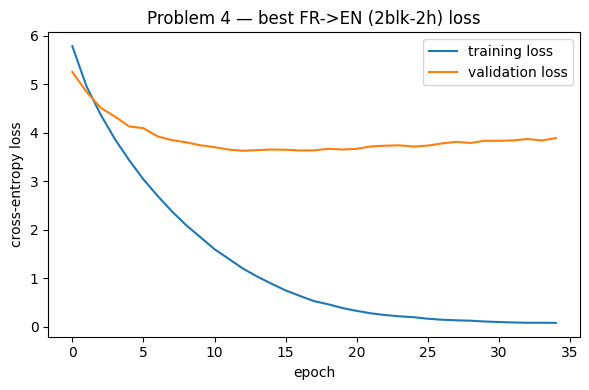


Qualitative validation — best FR->EN config (2blk-2h):

SRC : ils nourrissent les pigeons sur la place
PRED: they feed the ducks in the pond
TGT : they feed the pigeons in the square
      exact_match=False  sentence_BLEU-4=0.243

SRC : elle pratique le yoga tous les matins
PRED: she practices the cello for the morning
TGT : she practices yoga every morning
      exact_match=False  sentence_BLEU-4=0.091

SRC : j'aime marcher dans la neige
PRED: i enjoy walking in the dense forest
TGT : i enjoy walking in the snow
      exact_match=False  sentence_BLEU-4=0.615

SRC : elle adore porter des vestes modernes
PRED: she loves to wear modern leather jackets
TGT : she loves to wear modern jackets
      exact_match=False  sentence_BLEU-4=0.643

SRC : le bus de la ville arrive précisément à cinq heures
PRED: the city at five o'clock
TGT : the city bus arrives precisely at five o'clock
      exact_match=False  sentence_BLEU-4=0.207

SRC : nous avons visité les ruines historiques de la pyramide
PR

In [30]:
best_label_fren = df_p4.sort_values("bleu4", ascending=False).iloc[0]["label"]
best_model_fr, best_vocabs_fr, best_hist_fr, best_res_fr = runs_fren[best_label_fren]
print("Best FR->EN config by BLEU-4:", best_label_fren)

tr, va = best_hist_fr
plt.figure(figsize=(6, 4))
plt.plot(tr, label="training loss"); plt.plot(va, label="validation loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title(f"Problem 4 — best FR->EN ({best_label_fren}) loss"); plt.legend()
plt.tight_layout(); plt.show()

print(f"\nQualitative validation — best FR->EN config ({best_label_fren}):\n")
show_samples(best_model_fr, best_vocabs_fr, view("fr-en")[1], k=6)


In [31]:
cmp_p4 = pd.concat([
    pd.DataFrame([{**best_res_fr, "label": f"Transformer ({best_label_fren})"}]),
    hw3[hw3.direction == "fr-en"],
], ignore_index=True)[["label","attention","seq_acc","bleu4","final_train_loss","final_val_loss","train_time_s","params"]]
cmp_p4


,label,attention,seq_acc,bleu4,final_train_loss,final_val_loss,train_time_s,params
0,Transformer (2blk-2h),NaN,0.0,0.1776,0.083200,3.8898,11.2,3351169.0
1,GRU baseline,False,0.0,0.1328,0.002252,6.0396,398.4,NaN
2,GRU + attention,True,0.0,0.1088,0.225729,4.8674,567.5,NaN


In [32]:
for d, df in [("en-fr", df_p3), ("fr-en", df_p4)]:
    print(f"{d}:  avg val loss {df.final_val_loss.mean():.3f} | "
          f"avg BLEU-4 {df.bleu4.mean():.4f} | avg seq acc {df.seq_acc.mean()*100:.2f}% | "
          f"best BLEU-4 {df.bleu4.max():.4f}")


en-fr:  avg val loss 4.197 | avg BLEU-4 0.1754 | avg seq acc 0.15% | best BLEU-4 0.1898
fr-en:  avg val loss 3.950 | avg BLEU-4 0.1600 | avg seq acc 0.00% | best BLEU-4 0.1776
